# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [126]:
# importar librerías

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [127]:
# cargar archivos

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [128]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [129]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [130]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [131]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [132]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [133]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [134]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [135]:
print ("Cantidad de nulos para users")
print(users.isna().sum())
print()
print("Proporcion de nulos para users")
print(users.isna().mean())

Cantidad de nulos para users
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporcion de nulos para users
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [136]:

print ("Cantidad de nulos para usage")
print(usage.isna().sum())
print()
print ("Proporcion de nulos para usage")
print(usage.isna().mean())

Cantidad de nulos para usage
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporcion de nulos para usage
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### Analisis de Valores nulos

#### `users`
- **city (11.73%)**: proporción moderada de nulos. Se recomienda investigar otras posibles fuentes de ubicacion para imputación o mantener una categoría "Unknown".
- **churn_date (88.35%)**: proporción muy alta de nulos, probablemente asociada a usuarios activos. Se conservarán los nulos por su significado de negocio.

#### `usage`
- **date (0.13%)**: proporción mínima de nulos. Se pueden eliminar o imputar los registros afectados.
- **duration (55.19%)**: porcentaje elevado de nulos. Es necesario verificar si solo aplica a registros de llamadas.
- **length (44.74%)**: porcentaje elevado de nulos. Es necesario verificar si solo aplica a registros de mensajes.

**Decisión:** Antes de imputar `duration` y `length`, se analizará su relación con la variable `type`, ya que los valores faltantes podrían ser estructurales y esperados.



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [137]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` es un identificador unico consecutivo
- La columna `age` tiene maximo de edad 79, lo cual es razonable, pero cuenta con valores anomalos como -999, lo cual podria explicar la alta desviacion estandar que posee

In [138]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` son identificadores unicos, mientras el user_id muestra los usuarios asociados a cada registro, el id muestra registros que pueden estar asociados a mas de un usuario
- Las columnas "Duration" y "Length" presentan una cantidad importante de valores faltantes (aproximadamente el 55% y el 45% de los registros, respectivamente), por lo que es necesario evaluar la calidad de los datos antes de realizar análisis más avanzados. En ambos casos, la distribución muestra una fuerte presencia de valores extremos

In [139]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print("Columnas categoricas de Users")
print(users[columnas_user].describe())

Columnas categoricas de Users
          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` presenta algunos valores faltantes, dado que tiene menos registros no nulos que el total del dataset.
- La columna `plan` tiene a Bogotá como la ciudad predominante dentro del conjunto de datos y el plan Básico es el más utilizado por los clientes.

In [140]:
# explorar columna categórica de usage
print("Columnas categoricas de Usage")
usage['type'].describe()




Columnas categoricas de Usage


count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` no presenta datos faltantes y tiene únicamente 2 categorías diferentes, aunque "Text" concentra mas de la mitad de los registros, no hay un desbalanceo muy proporcional


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?:
Columnas como "Age" tienen valores invalidos, siendo estos -999
  
- ¿Qué acción tomarías?:
Imputar valores invalidos en la columna "Age", tomando en cuenta que la edad maxima edad es 79

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [141]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')




In [142]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')


In [143]:
# Revisar los años presentes en `reg_date` de users

years_count = users['reg_date'].dt.year.value_counts().sort_index()
print("Cantidad de registros por año:")
print(years_count)

Cantidad de registros por año:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, existen 40 valores con fechas de un año futuro.

In [144]:
# Revisar los años presentes en `date` de usage
years_count = usage['date'].dt.year.value_counts().sort_index()
print("Cantidad de registros por año:")
print(years_count)

Cantidad de registros por año:
2024.0    39950
Name: date, dtype: int64


En `date`, tenemos un solo registro de un año, el 2024  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos): Si, tenemos 40 registros del año 2026 en Users y basados en el dataset, ese año aun no transcurre.
- ¿Qué harías con ellas?: Al tratarse de solo del 1% del dataset de "Users", marcar como nulos estos datos no tendrian un impacto significativo en el analisis posterior

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [145]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [146]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [147]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [148]:
# Verificación MAR en usage (Missing At Random) para duration


usage.groupby('type')['duration'].apply(
    lambda x: x.isna().mean() * 100
)



type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [149]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(
    lambda x: x.isna().mean() * 100
)


type
call    99.932991
text     0.000000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**Duration:**
Los registros de tipo call tienen valores de duración prácticamente completos.
Los registros de tipo text tienen la duración nula en el 99.93% de los casos.
Esto indica que la variable duration solo es relevante para las llamadas y no para los mensajes de texto.


**Length**
Los registros de tipo text tienen valores de longitud completos.
Los registros de tipo call presentan valores nulos en el 99.93% de los casos.
Esto indica que la variable length solo aplica a los mensajes de texto y no a las llamadas.

**Conclusion**
El análisis mediante groupby() mostró que los valores nulos de duration y length dependen directamente de la variable type. La duración (duration) solo aplica a registros de llamadas (call), mientras que la longitud del mensaje (length) solo aplica a registros de texto (text). Por lo tanto, los valores faltantes son consistentes con la estructura del negocio y no representan errores de calidad de datos. Se decidió conservar estos nulos sin imputarlos ni eliminar registros, ya que contienen información implícita sobre el tipo de uso registrado.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [150]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [151]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
        })
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [152]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
)
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [153]:

# Resumen estadístico de las columnas numéricas
user_profile[["age","cant_mensajes","cant_llamadas","cant_minutos_llamada"]].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [154]:
# Distribución porcentual del tipo de plan
users["plan"].value_counts(normalize=True)

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

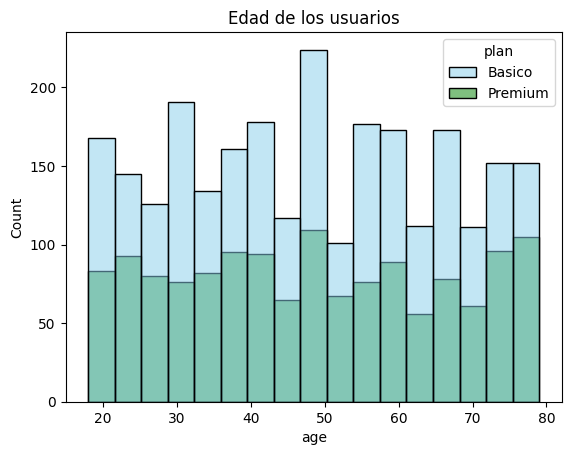

In [155]:


# Histograma para visualizar la edad (age)
sns.histplot(data = user_profile, x= "age",hue='plan',
palette=['skyblue','green'])
plt.title ("Edad de los usuarios")
plt.show()




💡Insights: 
- Distribución de edades en los usuarios de planes Básico y Premium es bastante similar,no hay sesgo, es simetrica, con una mayor concentración alrededor de los 50 años. Esto indica que la edad no actúa como un factor diferenciador entre planes, ya que ambos segmentos presentan patrones de comportamiento etario prácticamente equivalentes.

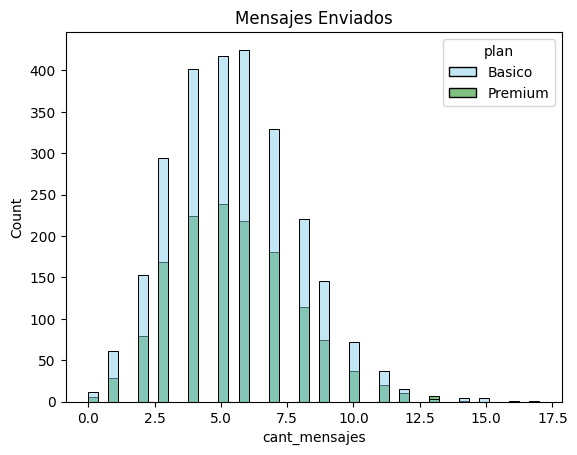

In [156]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data = user_profile, x= "cant_mensajes",hue='plan',
palette=['skyblue','green'])
plt.title ("Mensajes Enviados")
plt.show()



💡Insights: 
- La distribución de la cantidad de mensajes es asimétrica positiva (sesgada a la derecha), donde la mayoría de usuarios concentra un bajo número de mensajes y pocos usuarios alcanzan valores altos. Esto sugiere un comportamiento de uso poco intensivo en general. Adicionalmente, no se observan diferencias relevantes entre los planes Básico y Premium, lo que indica que el tipo de plan no parece ser un factor determinante en la cantidad de mensajes enviados.

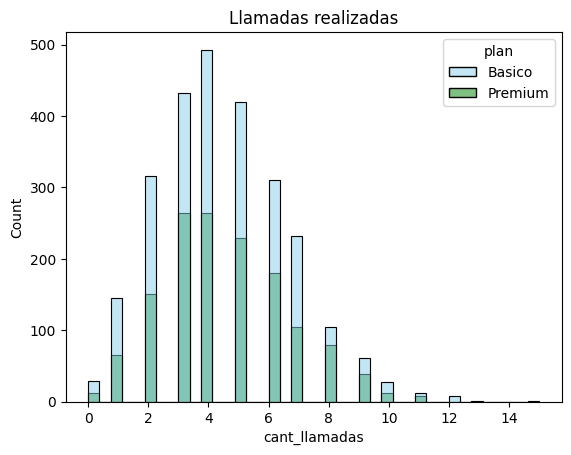

In [157]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data = user_profile, x= "cant_llamadas",hue='plan',
palette=['skyblue','green'])
plt.title ("Llamadas realizadas")
plt.show()


💡Insights: 
- La distribución del número de llamadas presenta un claro sesgo a la derecha, donde la mayoría de usuarios realiza pocas llamadas y solo un grupo reducido alcanza valores altos. Este patrón sugiere un uso generalmente bajo del servicio de llamadas. Además, no se observan diferencias significativas entre los planes Básico y Premium, lo que indica que el tipo de plan no influye de forma determinante en la cantidad de llamadas realizadas.

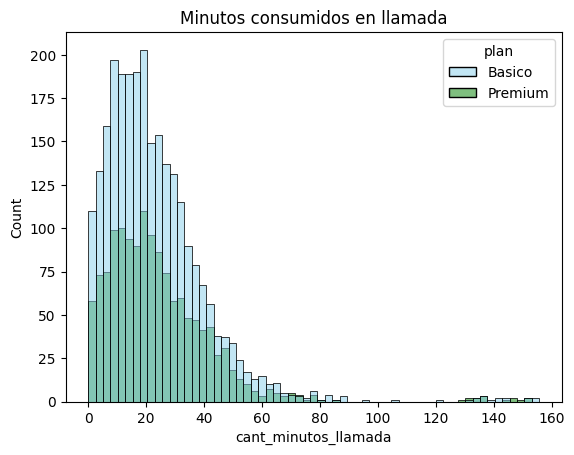

In [158]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data = user_profile, x= "cant_minutos_llamada",hue='plan',
palette=['skyblue','green'])
plt.title ("Minutos consumidos en llamada")
plt.show()

💡Insights: 
- La distribución de minutos consumidos en llamadas muestra un claro sesgo a la derecha, donde la mayoría de usuarios concentra un uso bajo, con un pico alrededor de los 20 minutos. Esto indica que el consumo típico de llamadas es reducido y que solo pocos usuarios utilizan grandes volúmenes de minutos. Además, no se observan diferencias significativas entre los planes Básico y Premium, lo que sugiere que el tipo de plan no es un factor determinante en el uso de minutos de llamada.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

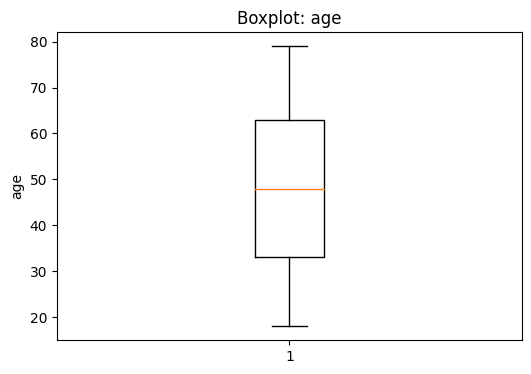

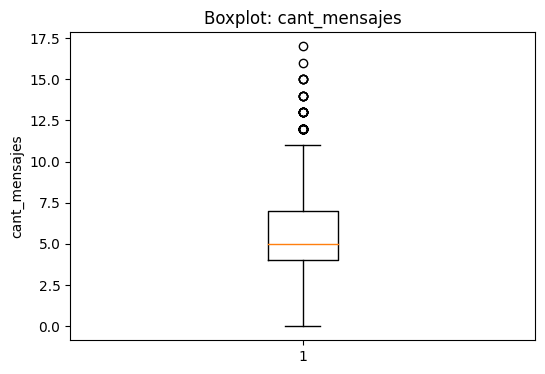

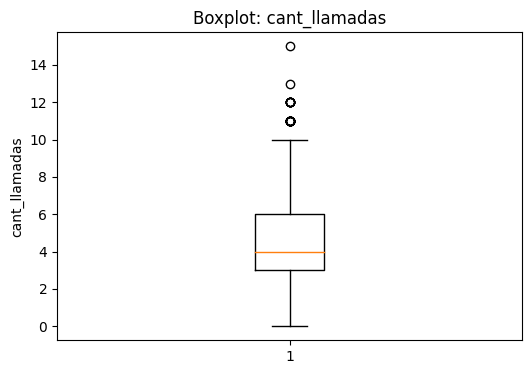

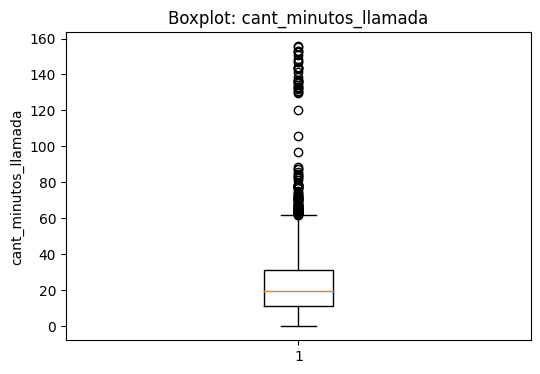

In [159]:
# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    plt.boxplot(user_profile[col].dropna())
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()


💡Insights: 
- **Age:** No presenta outliers relevantes, lo que indica una distribución estable de la edad en la muestra.
- **cant_mensajes:** Presenta outliers moderados en la cola superior, asociados a usuarios con alta actividad de mensajería.
- **cant_llamadas:** Presenta pocos outliers, lo que sugiere que existen algunos usuarios con mayor uso de llamadas, pero no es un fenómeno generalizado.
- **cant_minutos_llamada:** Presenta una alta cantidad de outliers en la cola superior, indicando la presencia de usuarios con consumo de minutos significativamente mayor al promedio.

In [160]:
# Calcular límites con el método IQR

columnas_numericas = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

columnas_limites = []

for col in columnas_numericas:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    columnas_limites.append([col, limite_superior])

columnas_limites = pd.DataFrame(
    columnas_limites,
    columns=['variable', 'limite_superior']
)

columnas_limites

,variable,limite_superior
0,cant_mensajes,11.5000
1,cant_llamadas,10.5000
2,cant_minutos_llamada,61.8575


In [161]:

# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_numericas].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- **cant_mensajes: mantener o no outliers, porqué?**
  Se decide mantener los outliers ya que, aunque existen usuarios con un número alto de mensajes, estos valores son coherentes con el comportamiento natural del consumo. La distribución está sesgada a la derecha y no se identifican valores imposibles o errores en los datos, por lo que representan usuarios con mayor nivel de actividad.
  
- **cant_llamadas: mantener o no outliers, porqué?**
- Los outliers se mantienen debido a que reflejan usuarios con un uso más intensivo del servicio de llamadas. Estos valores altos son consistentes con la variabilidad esperada en el comportamiento de los usuarios y no presentan indicios de ser datos erróneos o atípicos por calidad de datos.
  
- **cant_minutos_llamada: mantener o no outliers, porqué?**
- Se mantienen los outliers ya que representan usuarios con alto consumo de minutos, lo cual es coherente con la naturaleza del servicio. La presencia de valores elevados no indica errores, sino heterogeneidad en el uso, con algunos usuarios significativamente más activos que el promedio.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [162]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)


In [163]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [164]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    (user_profile['age'] < 30),
    'Joven',
    np.where(
        (user_profile['age'] < 60),
        'Adulto',
        'Adulto Mayor'
    )
)

In [165]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

In [166]:
user_profile["grupo_uso"].value_counts(normalize=True)

Uso medio    0.73575
Bajo uso     0.19450
Alto uso     0.06975
Name: grupo_uso, dtype: float64

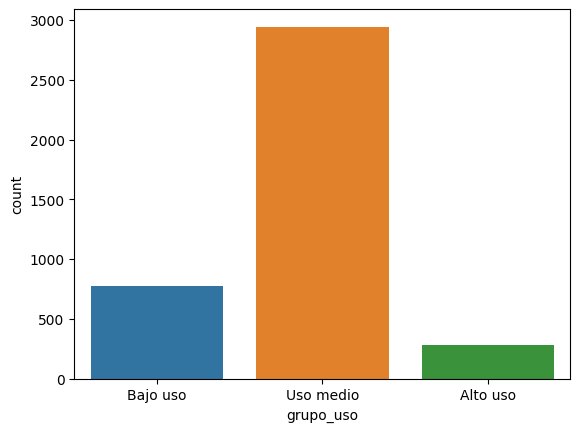

In [167]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.show()

In [168]:
user_profile["grupo_edad"].value_counts(normalize=True)

Adulto          0.5045
Adulto Mayor    0.3055
Joven           0.1900
Name: grupo_edad, dtype: float64

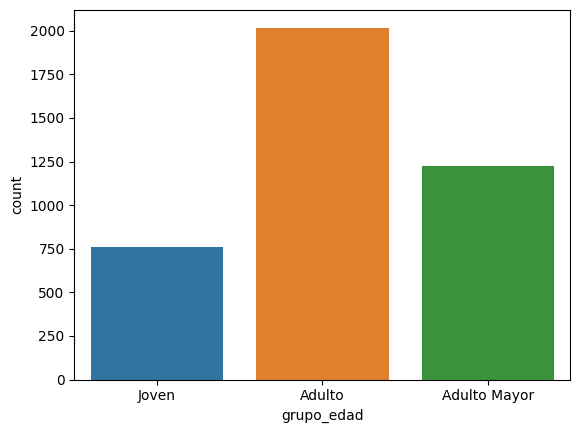

In [115]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron problemas de calidad en la variable edad, donde existían valores inconsistentes (ej. valores negativos o atípicos como -999 en etapas iniciales del análisis), lo que afectaba la interpretación estadística. Se reemplazaron estos datos atipicos, por una edad mediana.
- La columna City, tenia un total de 11.73% de datos nulos, sin embargo para el analisis de este reporte, no representaron impedimentos. De necesitarse, podrian reemplazarse nulos por "unknown"
- La columna reg_date tenia 40 fechas futuras (año 2026), se realizo una imputacion de estos datos a valores nulos (Nat), al representar solo el 1% de los registros.
- A pesar de que las columnas duration y length estaban con ~55% y ~45% de nulos estructurales, se determino que tenian logica dependiento de la variable "Type", se conservaron estos datos.
- Las variables de uso (mensajes, llamadas y minutos) no presentaron datos faltantes relevantes, pero sí alta dispersión.El principal problema inicial fue la calidad de la variable edad, no el volumen de datos.
- Los outliers no representan datos erroneos, pero si dispersion en el uso, como ejemplo tenemos cant_minutos_llamada donde el máximo fue 155.69 vs un límite de 61.86, dando oportunidad a una nueva categoria de plan por encima del premium solo para clientes selectos.


🔍 **Segmentos por Edad**
- La mayor concentración de clientes se encuentra en el segmento Adulto, que representa claramente el grupo dominante en la base de usuarios siendo estos el 50% de los clientes, seguido por Adulto Mayor (30%), mientras que los Jóvenes (menores de 30 años) son el segmento menos representado con un 19%, y tiene oportunidad de crecimiento.


📊 **Segmentos por Nivel de Uso**
- La mayoria de los usuarios, el 73%, tiene un uso medio de sus planes, los que concentran un alto uso, representan la minoria siendo solo el 6%, y los de bajo uso tienen oportunidad de crecimiento en consumo representando el 19%, (porcentaje que coincide con el segmento porcentual de Jovenes, podria haber una relacion directa con la edad vs el consumo. Un mayor consumo representaria potenciales actualizaciones a planes premium en caso de tener planes basicos, se debe incentivar un mayor consumo del plan, manteniendo al usuario informado acerca de los beneficios del mismo, con un uso de notificaciones ocasionales o una guia corta al momento de la suscripcion 


➡️ Esto sugiere que ...
- Los usuarios de uso medio concentran la mayor cantidad y es el segmento mas valioso al representar un 73% de los usuarios totales, en donde hay opciones de upselling para planes premium, tomando en cuenta que el 65% usa plan Básico y 35% Premium, hay oportunidades para actualizaciones de plan. 


💡 **Recomendaciones**
- Incentivar el uso en usuarios jovenes con campañas publicitarias para incrementar ese sector de clientes, hacer mas uso de redes sociales o pautas pagas con influenciadores para llegar a una poblacion objetivo mas joven.
- Promover los beneficios de cada plan para realizar upsellings a planes premium

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`